# Machine Learning
Innerhalb eines gegebenen Datensets Zusammenhänge erkennen

Aus diese Zusammenhängen neue Erkenntnisse bestimmen

-> Aus neuen Daten "Vorhersagen" treffen

---

Model:

Ergebnis des Lernprozesses

Binary, welches auf beliebigen Geräten verwendet werden kann, um mit neuen Daten Vorhersagen zu treffen

Neue Daten müssen die selbe Struktur haben, wie die Trainigsdaten

---

Beispiel: Wettermodell

Parameter: Datum, Uhrzeit, Wolken %, Niederschlag % -> Temperatur



## Income.csv
Enthält Personendaten, welche beschreiben, ob eine gegebene Person über/unter 50k$ pro Jahr verdient

Über ML soll dann die Frage beantwortet werden

In [27]:
from tarfile import LNKTYPE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
data = pd.read_csv("data/Income.csv")

In [29]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


### Datenset anpassen
Das Datenset ist noch nicht für ML verwendbar
- Text durch Zahlen ersetzen
- Skalieren (Outlier entfernen)
- Unebnheiten inder class-Spalte ausgleichen

In [30]:
(data["class"]==">50K").astype(int)
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [31]:
data["class"]=(data["class"]==">50K").astype(int)

#### Werte numerisch machen
mit LabelEncoder

Weist jedem Text eine eigene Nummer zu, ersetzt alle Texte mit der gegebenen Nummer

neues Paket: scikit-learn

In [32]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
data["workclass"] = enc.fit_transform(data["workclass"])


In [33]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,7,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,6,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,4,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,4,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,4,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
32557,40,4,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
32558,58,4,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
32559,22,4,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


alle Spalten konvertieren, welche vom Typ object sind

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   gender          32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  class           32561 non-null  int64
dtypes: int64(8), str(7)
memory usage: 3.7 MB


In [35]:
for col in data.select_dtypes(str).columns: #select_dtypes wird es in Zukunft mit object nicht mehr geben
    data[col] = enc.fit_transform(data[col])

In [36]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,class
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39,0


### Aufteilen
Das Datenset in Trainigsdaten und Testdaten teilen

Und zusätzlich muss die linke Seite des DS (die Daten) von der Klasse getrennt werden (Label)

In [37]:
random= data.sample(frac=1)
p80 = int(len(random)*0.8)
training = random [0:p80]
test =  random[p80:]

training_left = training.iloc[:, 0:-1]
training_right = training.iloc[:, -1]

test_left = test.iloc[:, 0:-1]
test_right = test.iloc[:, -1]

### Skalieren
Outlier entfernen, Zahlen im Datenset "normalisieren"

In [38]:
from sklearn.preprocessing import StandardScaler
scaler =StandardScaler()
training_left= pd.DataFrame(scaler.fit_transform(training_left))

scaler =StandardScaler()
test_left= pd.DataFrame(scaler.fit_transform(test_left))


In [39]:
training_left

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-1.589683,-2.665138,-0.186182,-2.420806,-1.203801,0.924524,-1.558808,0.964468,0.393480,-1.419073,-0.146039,-0.214621,-2.640948,0.289448
1,-1.442622,2.153888,3.277571,1.220193,-0.035507,0.924524,-1.322373,0.343209,0.393480,-1.419073,-0.146039,-0.214621,-2.071509,-1.648041
2,-1.074969,-1.288273,0.551406,1.220193,-0.035507,-1.726000,-0.140201,-0.278050,-1.965409,0.704685,-0.146039,-0.214621,0.775686,0.289448
3,0.027989,0.088591,-0.686632,0.179907,-0.424939,0.924524,1.514839,-0.278050,0.393480,0.704685,-0.146039,-0.214621,1.751868,-3.585530
4,0.763294,0.088591,-0.129263,-0.340235,1.132786,0.924524,1.514839,1.585728,-3.144854,-1.419073,-0.146039,-0.214621,-0.037798,-2.293871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26043,0.836825,0.088591,-0.582674,-1.640592,-2.761525,-0.400738,-0.140201,-0.899309,0.393480,0.704685,-0.146039,-0.214621,1.182429,-4.748023
26044,-0.633786,0.088591,-0.772979,-0.340235,1.132786,-0.400738,0.805536,-0.899309,0.393480,0.704685,-0.146039,-0.214621,-0.037798,0.289448
26045,1.939783,0.088591,-0.439210,1.220193,-0.035507,1.587155,-1.322373,-0.278050,0.393480,-1.419073,-0.146039,-0.214621,-0.200495,0.289448
26046,-1.295561,0.088591,0.095840,0.179907,-0.424939,0.924524,0.332667,0.964468,0.393480,-1.419073,-0.146039,-0.214621,-0.688585,0.289448


### Unebenheiten ausbessern
Klassen ausgleichen

Verhindern, dass beim ML Prozess ein Bias entwickelt wird

WICHIG: Nur beim Testset nicht

In [41]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
left, right = ros.fit_resample(training_left, training_right)

In [42]:
left

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-1.589683,-2.665138,-0.186182,-2.420806,-1.203801,0.924524,-1.558808,0.964468,0.393480,-1.419073,-0.146039,-0.214621,-2.640948,0.289448
1,-1.442622,2.153888,3.277571,1.220193,-0.035507,0.924524,-1.322373,0.343209,0.393480,-1.419073,-0.146039,-0.214621,-2.071509,-1.648041
2,-1.074969,-1.288273,0.551406,1.220193,-0.035507,-1.726000,-0.140201,-0.278050,-1.965409,0.704685,-0.146039,-0.214621,0.775686,0.289448
3,0.027989,0.088591,-0.686632,0.179907,-0.424939,0.924524,1.514839,-0.278050,0.393480,0.704685,-0.146039,-0.214621,1.751868,-3.585530
4,0.763294,0.088591,-0.129263,-0.340235,1.132786,0.924524,1.514839,1.585728,-3.144854,-1.419073,-0.146039,-0.214621,-0.037798,-2.293871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39519,1.130947,0.777024,1.584203,-0.340235,1.132786,-0.400738,-0.613070,-0.899309,0.393480,0.704685,0.842469,-0.214621,1.182429,0.289448
39520,0.836825,0.777024,0.476063,0.439979,1.522217,-0.400738,1.278405,-0.899309,0.393480,0.704685,-0.146039,-0.214621,-0.037798,0.289448
39521,1.425069,0.088591,-0.289620,0.179907,-0.424939,-0.400738,0.096233,-0.899309,0.393480,0.704685,-0.146039,-0.214621,0.368944,0.289448
39522,0.763294,-1.288273,2.035250,-0.600307,0.353924,-0.400738,-0.849505,-0.899309,0.393480,0.704685,-0.146039,-0.214621,-0.037798,0.289448


In [43]:
training_left = pd.DataFrame(left)
training_right = pd.DataFrame(right)

## Verschiedene vorgegebene Algorithmen
k-nearest Neighbort (kNN)
- Neuer Datensatz soll klassifiziert werden
- Nachbarn (ähnliche Datensätze) werden auf Klasse überprüft
- Über den Wert k (Anzahl), wird die Klasse andhand der Anzahl der Datneätze in der Umgebung ausgewählt

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
knn = KNeighborsClassifier(n_neighbors=7)

In [46]:
knn_model = knn.fit(training_left, training_right.values.reshape(-1)) # Mashine learning gestartet

In [47]:
prediction = knn_model.predict(test_left)

In [48]:
vc = (prediction == test_right).value_counts()

In [49]:
vc[False]/vc[True]

np.float64(0.27555816686251466)

In [54]:
def eval(model):
    prediction = model.predict(test_left)
    vc = (prediction==test_right).value_counts()
    print(f"Richtige Vorhersagen: {(1-vc[False]/vc[True])*100}%")

In [55]:
eval(knn_model)

Richtige Vorhersagen: 72.44418331374854%


### Logische Regression
- Vergleicht den Gesamtdatensatz mit einem Grenzwert (Standart 0.5)
- Ist der Gesamtwert über dem Grenzwert, wied die Klasse mit 1 Beschrieben

In [56]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [57]:
lr_model = lr.fit(training_left, training_right.values.reshape(-1))

In [58]:
eval(lr_model)

Richtige Vorhersagen: 71.00415923945336%


### Support Vector Machines
- Legt eine Hyperplane (H) in den Raum
- Breitet sich im Anschluss von der Hyperplane ein Margin aus
- Alle Datenpunkte, die von dem Margin getroffen werden, werden je nach Seite klassifiziert

In [59]:
from sklearn.svm import SVC
svc = SVC()

In [60]:
svc_model = svc.fit(training_left, training_right.values.reshape(-1))

In [61]:
eval(svc_model)

Richtige Vorhersagen: 74.48448641356717%


---
### Neuronales Netz

Modell, welches aus Schichten und Neuronen besteht

Jede Schicht wird mit einem Neuronentypen definiert

Jedes Neuron muss eine Activation Funciton haben

Modelle lassen sich aufbauen mithilfe von Keras

In [63]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

model= tf.keras.Sequential([
    Input((14,)), # Input: Beschreibt die Form der Daten (14 Spalten, X Zeilen)
    Dense(32, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid") # Output Layer
]);

In [64]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.compile(loss="binary_crossentropy") # binary_crossentropy: Erfolgsmessung anhand von 0 oder 1

In [66]:
x = model.fit(training_left, training_right.values.reshape(-1), verbose=1, epochs=20)

Epoch 1/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4322
Epoch 2/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3919
Epoch 3/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3846
Epoch 4/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3801
Epoch 5/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3766
Epoch 6/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3745
Epoch 7/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3723
Epoch 8/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3697
Epoch 9/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3680
Epoch 10/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3663
Epoch 11/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3646
Epoch 12/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3632
Epoch 13/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3622
Epoch 14/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3611
Epoch 15/20
1236/1236 ━━━━━━━

In [67]:
model.save("Models/Income.keras")

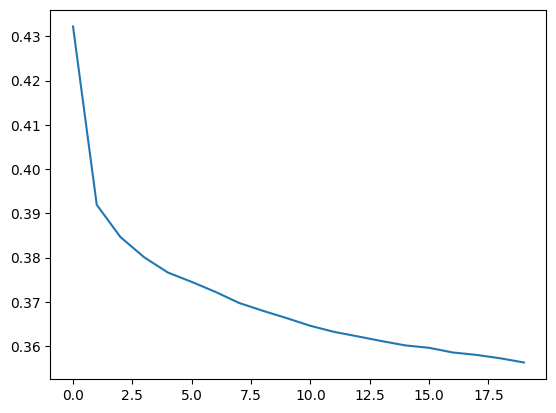

In [68]:
plt.plot(x.history["loss"])

In [69]:
x = model.fit(training_left, training_right.values.reshape(-1), verbose=1, epochs=20)

Epoch 1/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3562
Epoch 2/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3555
Epoch 3/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3546
Epoch 4/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3541
Epoch 5/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3534
Epoch 6/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3530
Epoch 7/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3519
Epoch 8/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3512
Epoch 9/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3503
Epoch 10/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3499
Epoch 11/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3496
Epoch 12/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3494
Epoch 13/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3491
Epoch 14/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3483
Epoch 15/20
1236/1236 ━━━━━━━

In [70]:
x = model.fit(training_left, training_right.values.reshape(-1), verbose=1, epochs=20)

Epoch 1/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3466
Epoch 2/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3464
Epoch 3/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3461
Epoch 4/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3452
Epoch 5/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3454
Epoch 6/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3450
Epoch 7/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3449
Epoch 8/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3446
Epoch 9/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3449
Epoch 10/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3437
Epoch 11/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3434
Epoch 12/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3433
Epoch 13/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3423
Epoch 14/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3427
Epoch 15/20
1236/1236 ━━━━━━━

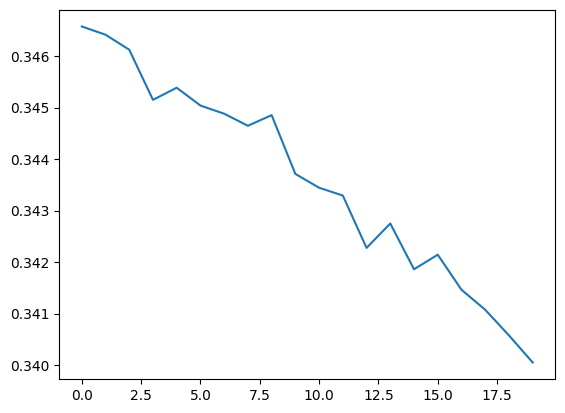

In [71]:
plt.plot(x.history["loss"])

In [73]:
x.history

{'loss': [0.3465774357318878,
  0.3464178442955017,
  0.346125990152359,
  0.3451516628265381,
  0.34538739919662476,
  0.3450411558151245,
  0.34488222002983093,
  0.34464794397354126,
  0.3448545038700104,
  0.3437126576900482,
  0.34344419836997986,
  0.3432922065258026,
  0.34227505326271057,
  0.3427489697933197,
  0.3418598473072052,
  0.3421429395675659,
  0.3414616882801056,
  0.34107306599617004,
  0.3405750095844269,
  0.34004881978034973]}

In [74]:
x

In [76]:
right_pred = model.predict(test_left)

204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [77]:
right_pred

array([[4.3525904e-01],
       [1.1170575e-01],
       [1.0346454e-09],
       ...,
       [9.7143543e-01],
       [2.9379398e-02],
       [7.8022626e-04]], shape=(6513, 1), dtype=float32)

In [89]:
(right_pred>0.5).reshape(-1).astype(int)


array([0, 0, 0, ..., 1, 0, 0], shape=(6513,))

In [90]:
r = (test_right==(right_pred>0.5).reshape(-1))

In [91]:
r.value_counts()

class
True     5368
False    1145
Name: count, dtype: int64

In [93]:
(1-r.value_counts()[False] / r.value_counts()[True])*100

np.float64(78.66989567809239)